Model performance (test set):
Seasonal Naive RMSE: 3198710.35
ETS RMSE:            5516043.00


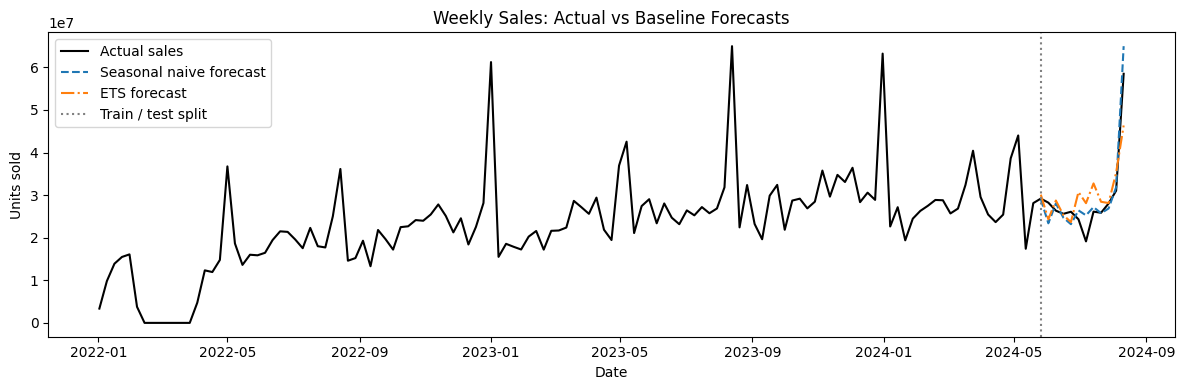

In [9]:
# ======================================
# Demand Forecasting: Baseline Models
# Seasonal Naive vs ETS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# --------------------------------------
# 1. Load and prepare data
# --------------------------------------

# Load cleaned data
df = pd.read_excel("Sample_data_cleaned.xlsx")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# --------------------------------------
# 2. Aggregate daily data to weekly
# --------------------------------------

# Weekly aggregation aligns with HQ planning horizon
df_weekly = (
    df
    .set_index("date")
    .resample("W")["sales"]
    .sum()
    .reset_index()
)

# --------------------------------------
# 3. Train–test split (time-based)
# --------------------------------------

test_horizon = 12  # last 12 weeks as test set

train = df_weekly.iloc[:-test_horizon]
test  = df_weekly.iloc[-test_horizon:]

y_train = train["sales"].values
y_test  = test["sales"].values

dates_train = train["date"]
dates_test  = test["date"]

# --------------------------------------
# 4. Seasonal Naive Model
# --------------------------------------

# Weekly data with yearly seasonality
season_length = 52

# Seasonal naive forecast:
# y_hat(t+h) = y(t+h-52)
y_naive_forecast = y_train[-season_length:][:test_horizon]

# --------------------------------------
# 5. ETS Model (Additive Seasonality)
# --------------------------------------

ets_model = ExponentialSmoothing(
    y_train,
    trend=None,
    seasonal="add",
    seasonal_periods=season_length
)

ets_fit = ets_model.fit(optimized=True)

y_ets_forecast = ets_fit.forecast(test_horizon)

# --------------------------------------
# 6. RMSE Evaluation
# --------------------------------------

rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive_forecast))
rmse_ets   = np.sqrt(mean_squared_error(y_test, y_ets_forecast))


print("Model performance (test set):")
print(f"Seasonal Naive RMSE: {rmse_naive:.2f}")
print(f"ETS RMSE:            {rmse_ets:.2f}")

# --------------------------------------
# 7. Visualization: Actual vs Forecasts
# --------------------------------------

plt.figure(figsize=(12, 4))

# Actual data
plt.plot(
    df_weekly["date"],
    df_weekly["sales"],
    label="Actual sales",
    color="black"
)

# Seasonal naive forecast
plt.plot(
    dates_test,
    y_naive_forecast,
    linestyle="--",
    label="Seasonal naive forecast"
)

# ETS forecast
plt.plot(
    dates_test,
    y_ets_forecast,
    linestyle="-.",
    label="ETS forecast"
)

# Train-test split marker
plt.axvline(
    dates_test.iloc[0],
    color="gray",
    linestyle=":",
    label="Train / test split"
)

plt.title("Weekly Sales: Actual vs Baseline Forecasts")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.tight_layout()
plt.show()

Model performance (test set):
XGBoost RMSE: 2784754.40


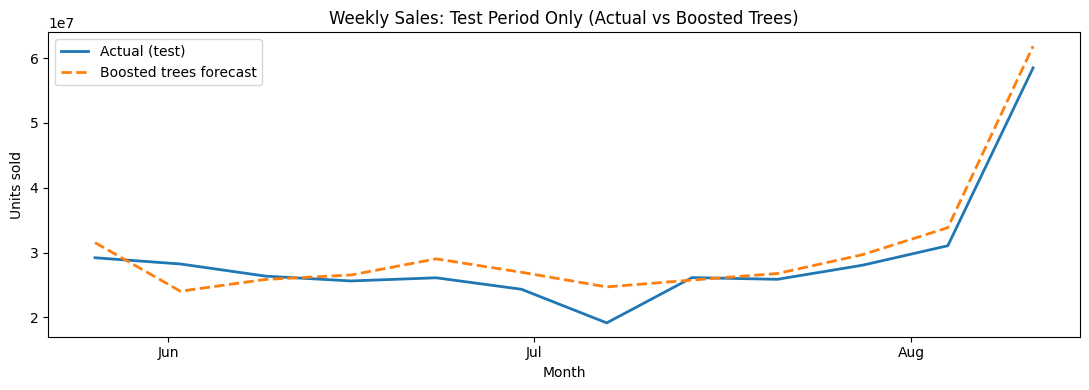

In [10]:
# ======================================
# Demand Forecasting: XGBoost Tree Baseline
# Weekly aggregation + time features
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

# --- Try to use XGBoost; fallback to sklearn if not installed ---
try:
    from xgboost import XGBRegressor
    USING_XGBOOST = True
except Exception:
    USING_XGBOOST = False
    from sklearn.ensemble import HistGradientBoostingRegressor


# --------------------------------------
# 0. Helper: week of month
# --------------------------------------
def week_of_month(dt: pd.Timestamp) -> int:
    """
    Week of month in [1..5] roughly, based on day-of-month.
    For weekly aggregated data, this is a coarse "within-month position".
    """
    return int((dt.day - 1) // 7) + 1


# --------------------------------------
# 1. Load and prepare data
# --------------------------------------
df = pd.read_excel("Sample_data_cleaned.xlsx")
df["date"] = pd.to_datetime(df["date"])

# Assumes columns: ["date", "sales"]


# --------------------------------------
# 2. Aggregate daily data to weekly
# --------------------------------------
df_weekly = (
    df.set_index("date")
      .resample("W")["sales"]
      .sum()
      .reset_index()
)

# --------------------------------------
# 3. Feature engineering (time features)
# --------------------------------------
df_weekly["year"] = df_weekly["date"].dt.year
df_weekly["month"] = df_weekly["date"].dt.month
df_weekly["week_of_month"] = df_weekly["date"].apply(week_of_month)

# Often helpful for weekly data seasonality
df_weekly["weekofyear"] = df_weekly["date"].dt.isocalendar().week.astype(int)

FEATURES = ["year", "month", "week_of_month", "weekofyear"]
TARGET = "sales"


# --------------------------------------
# 4. Train–test split (time-based)
# --------------------------------------
test_horizon = 12  # last 12 weeks as test

train = df_weekly.iloc[:-test_horizon].copy()
test  = df_weekly.iloc[-test_horizon:].copy()

X_train = train[FEATURES].values
y_train = train[TARGET].values

X_test = test[FEATURES].values
y_test = test[TARGET].values

dates_test = test["date"]


# --------------------------------------
# 5. Fit XGBoost Tree Model
# --------------------------------------
if USING_XGBOOST:
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
    )
else:
    # fallback (not "XGBoost", but still a tree boosting baseline)
    model = HistGradientBoostingRegressor(
        max_depth=4,
        learning_rate=0.05,
        max_iter=500,
        random_state=42
    )

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# --------------------------------------
# 6. RMSE Evaluation
# --------------------------------------
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model performance (test set):")
print(f"{'XGBoost' if USING_XGBOOST else 'HistGradientBoosting'} RMSE: {rmse_xgb:.2f}")


# --------------------------------------
# 7. Visualization: ONLY test period
# --------------------------------------
plt.figure(figsize=(11, 4))

plt.plot(dates_test, y_test, label="Actual (test)", linewidth=2)
plt.plot(dates_test, y_pred, linestyle="--", label="Boosted trees forecast", linewidth=2)

plt.title("Weekly Sales: Test Period Only (Actual vs Boosted Trees)")
plt.xlabel("Month")
plt.ylabel("Units sold")

# Make x-axis show months clearly
ax = plt.gca()
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

plt.legend()
plt.tight_layout()
plt.show()
